## African International Football Games Analysis

This project evaluates the historical performance of African national football teams (1872–2026) using a custom ranking system.
Instead of relying only on win/loss counts, the model:
- Applies weighted importance to different tournaments
- Adjusts scores based on competition stage
- Accounts for goal difference
- Converts match results into a structured performance score

The outcome is a data-driven ranking system that measures long-term competitive strength, trend evolution, and head-to-head dominance among African teams

Contents:
- [Methodology](#Methodology)
- [International football dataset](#International-football-dataset)
- [Selecting African Teams' Games from different tournaments](#Selecting-African-Teams'-Games-from-different-tournaments)
- [Define the stages of every game in the African Cup of Nations](#Define-the-stages-of-every-game-in-the-African-Cup-of-Nations)
- [Weight of every match based on tournament and stage](#Weight-of-every-match-based-on-tournament-and-stage)
- [From Match Results to Team Performance Metrics](#From-Match-Results-to-Team-Performance-Metrics)
- [Final Data and Ranking Teams](#Final-Data-and-Ranking-Teams)
- [Summary Plots](#Summary-Plots)
  - [Top Teams by Total Points](#Top-Teams-by-Total-Points)
  - [Goal Difference vs Total Points (Validate Logic)](#Goal-Difference-vs-Total-Points-(Validate-Logic))
  - [Win Percentage vs Ranking](#Win-Percentage-vs-Ranking)
  - [Goals For vs Goals Against (Offense vs Defense)](#Goals-For-vs-Goals-Against-(Offense-vs-Defense))
  - [Wins / Draws / Losses Distribution (Stacked Bar)](#Wins-/-Draws-/-Losses-Distribution-(Stacked-Bar))
- [Through Years](#Through-Years)
  - [Plots](#Through-Years-Plot)
- [Head-to-head](#Head-to-head)
  - [Result Samples](#Result-Samples)
  - [Egypt Head to Head Plot](#Egypt-Head-to-Head-Plot)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Methodology

In [2]:
# Assumptions and AFCON System
GD_factor = 0.25
win_factor = 1.0
draw_factor = 0.5

# Weight of tournaments and stages
tournament_weight = {
    "African Cup of Nations": 2.0,
    "FIFA World Cup qualification": 2.0,
    "African Cup of Nations qualification": 1.5}

stage_weight = {
    "Group Stage": 1.0,
    "Round of 16": 1.5,
    "Quarter final": 1.75,
    "Semi final": 2.0,
    "Third Place": 1.75,
    "Final": 2.25}

# AFCON Tournament system through the years 
stages_2019_2027 = [("Final", 1), ("Third Place", 1), ("Semi final", 2), ("Quarter final", 4), ("Round of 16", 8),]
stages_1992_2019 = [("Final", 1), ("Third Place", 1), ("Semi final", 2), ("Quarter final", 4),]
stages_1978_1992 = [("Final", 1), ("Third Place", 1), ("Semi final", 2),]
stages_1968_1978 = [("Final", 1), ("Third Place", 1), ("Semi final", 2),]
stages_1963_1968 = [("Final", 1), ("Third Place", 1),]
stages_1976 = [("Final Group", 4),]

## International football dataset


In [3]:
# International football results (1872 to 2026)
df = pd.read_csv('results.csv')

In [4]:
df.tail(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49066,2026-01-18,Bolivia,Panama,1,1,Friendly,Tarija,Bolivia,False
49067,2026-01-18,Grenada,Jamaica,0,1,Friendly,St. George's,Grenada,False
49068,2026-01-22,Panama,Mexico,0,1,Friendly,Panama City,Panama,False
49069,2026-01-25,Bolivia,Mexico,0,1,Friendly,Santa Cruz,Bolivia,False
49070,2026-01-26,Uzbekistan,China PR,2,2,Friendly,Dubai,United Arab Emirates,True


## Selecting African Teams' Games from different tournaments


In [5]:
# African Cup of Nations from International football results (1872 to 2026)
afcon = df[df['tournament'] == 'African Cup of Nations']

In [6]:
afcon.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
4396,1957-02-10,Sudan,Egypt,1,2,African Cup of Nations,Khartoum,Sudan,False
4397,1957-02-16,Egypt,Ethiopia,4,0,African Cup of Nations,Khartoum,Sudan,True
4864,1959-05-22,Egypt,Ethiopia,4,0,African Cup of Nations,Cairo,United Arab Republic,True
4867,1959-05-25,Ethiopia,Sudan,0,1,African Cup of Nations,Cairo,United Arab Republic,True
4870,1959-05-29,Egypt,Sudan,2,1,African Cup of Nations,Cairo,United Arab Republic,True


In [7]:
# African Cup of Nations qualification from International football results (1872 to 2026)
afconq = df[df['tournament'] == 'African Cup of Nations qualification']

In [8]:
afconq.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
5241,1961-04-08,Nigeria,Ghana,0,0,African Cup of Nations qualification,Lagos,Nigeria,False
5255,1961-04-30,Ghana,Nigeria,2,2,African Cup of Nations qualification,Accra,Ghana,False
5310,1961-08-05,Kenya,Uganda,0,1,African Cup of Nations qualification,Nairobi,Kenya,False
5332,1961-09-23,Uganda,Kenya,0,1,African Cup of Nations qualification,Kampala,Uganda,False
5373,1961-10-29,Uganda,Kenya,2,0,African Cup of Nations qualification,Kampala,Uganda,False


In [9]:
# Naming all African teams
all_african_teams = pd.concat([
    afcon["home_team"], afcon["away_team"],
    afconq["home_team"], afconq["away_team"],])
african_teams = all_african_teams

In [10]:
# FIFA World Cup qualification from International football results (1872 to 2026)
fwcq = df[df['tournament'] == 'FIFA World Cup qualification'].drop_duplicates().reset_index(drop=True)

In [11]:
fwcq.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1933-06-11,Sweden,Estonia,6,2,FIFA World Cup qualification,Stockholm,Sweden,False
1,1933-06-29,Lithuania,Sweden,0,2,FIFA World Cup qualification,Kaunas,Lithuania,False
2,1933-09-24,Yugoslavia,Switzerland,2,2,FIFA World Cup qualification,Belgrade,Yugoslavia,False
3,1933-10-15,Poland,Czechoslovakia,1,2,FIFA World Cup qualification,Warsaw,Poland,False
4,1933-10-29,Switzerland,Romania,2,2,FIFA World Cup qualification,Bern,Switzerland,False


In [12]:
# Selecting only FIFA World Cup qualification matches from Africa
afwcq = fwcq[
    (fwcq["home_team"].isin(african_teams)) &
    (fwcq["away_team"].isin(african_teams))]

In [13]:
# Merging afcon, afconq, and afwcq to get African teams' games from the three tournaments
africa = pd.concat([afcon, afconq, afwcq])
africa["date"] = pd.to_datetime(africa["date"])
africa["year"] = africa["date"].dt.year

In [14]:
africa.head(6)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
4396,1957-02-10,Sudan,Egypt,1,2,African Cup of Nations,Khartoum,Sudan,False,1957
4397,1957-02-16,Egypt,Ethiopia,4,0,African Cup of Nations,Khartoum,Sudan,True,1957
4864,1959-05-22,Egypt,Ethiopia,4,0,African Cup of Nations,Cairo,United Arab Republic,True,1959
4867,1959-05-25,Ethiopia,Sudan,0,1,African Cup of Nations,Cairo,United Arab Republic,True,1959
4870,1959-05-29,Egypt,Sudan,2,1,African Cup of Nations,Cairo,United Arab Republic,True,1959
5438,1962-01-14,Ethiopia,Tunisia,4,2,African Cup of Nations,Addis Ababa,Ethiopia,False,1962


In [15]:
africa.tail(6)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
8675,2025-10-14,Algeria,Uganda,2,1,FIFA World Cup qualification,Tizi Ouzou,Algeria,False,2025
8676,2025-10-14,Guinea,Botswana,2,2,FIFA World Cup qualification,Casablanca,Morocco,True,2025
8677,2025-10-14,Somalia,Mozambique,0,1,FIFA World Cup qualification,Bir El Djir,Algeria,True,2025
8691,2025-11-13,Cameroon,DR Congo,0,1,FIFA World Cup qualification,Rabat,Morocco,True,2025
8692,2025-11-13,Nigeria,Gabon,4,1,FIFA World Cup qualification,Rabat,Morocco,True,2025
8723,2025-11-16,Nigeria,DR Congo,1,1,FIFA World Cup qualification,Rabat,Morocco,True,2025


## Define the stages of every game in the African Cup of Nations

In [16]:
# A function that defines the tournament system + applies the elimination disorder
def apply_afcon_knockout(df, year, year_idx):
    if year >= 2019:
        stages = stages_2019_2027
    elif year >= 1992:
        stages = stages_1992_2019
    elif year >= 1978:
        stages = stages_1978_1992
    elif year >= 1968:
        stages = stages_1968_1978        
    elif year >= 1963:
        stages = stages_1963_1968
    elif year == 1976:
        stages = stages_1976          
    else:
        return year_idx

    needed = sum(c for _, c in stages)
    if len(year_idx) < needed:
        return year_idx

    ptr = len(year_idx)
    for stage, count in stages:
        df.loc[year_idx[ptr - count:ptr], "stage"] = stage
        ptr -= count

    return year_idx[:ptr]

In [17]:
def stage(data):
    df = data.copy()

    # Ensure stage column exists
    if "stage" not in df.columns:
        df["stage"] = pd.NA

    # AFCON only
    mask = df["tournament"] == "African Cup of Nations"

    # Process each tournament year separately
    for year, idx in (
        df[mask]
        .sort_values("date")
        .groupby("year")
        .groups.items()
    ):
        year_idx = list(idx)

        # 1976 AFCON had NO knockout stages (final group system)
        if year == 1976:
            df.loc[year_idx, "stage"] = df.loc[year_idx, "stage"].fillna("Group Stage")
            continue

        # Apply knockout logic
        group_matches = apply_afcon_knockout(df, year, year_idx)

        # Remaining matches are group stage
        df.loc[group_matches, "stage"] = (
            df.loc[group_matches, "stage"]
            .fillna("Group Stage")
        )

    return df

In [18]:
# Applying function and selecting only important columns
africa_with_stages = stage(africa)
cols = ['year','date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'stage']
data = africa_with_stages[cols].copy()

In [19]:
data.head(5)

,year,date,home_team,away_team,home_score,away_score,tournament,stage
4396,1957,1957-02-10,Sudan,Egypt,1,2,African Cup of Nations,Group Stage
4397,1957,1957-02-16,Egypt,Ethiopia,4,0,African Cup of Nations,Group Stage
4864,1959,1959-05-22,Egypt,Ethiopia,4,0,African Cup of Nations,Group Stage
4867,1959,1959-05-25,Ethiopia,Sudan,0,1,African Cup of Nations,Group Stage
4870,1959,1959-05-29,Egypt,Sudan,2,1,African Cup of Nations,Group Stage


## Weight of every match based on tournament and stage

In [20]:
# Calculating every match value based on the Weight of the tournament and the stage
data["tournament_weight"] = data["tournament"].map(tournament_weight)
data["stage_weight"] = data["stage"].map(stage_weight).fillna(1.0)
data["match_value"] = (data["tournament_weight"] * data["stage_weight"])

In [21]:
data.tail(5)

,year,date,home_team,away_team,home_score,away_score,tournament,stage,tournament_weight,stage_weight,match_value
8676,2025,2025-10-14,Guinea,Botswana,2,2,FIFA World Cup qualification,<NA>,2.0,1.0,2.0
8677,2025,2025-10-14,Somalia,Mozambique,0,1,FIFA World Cup qualification,<NA>,2.0,1.0,2.0
8691,2025,2025-11-13,Cameroon,DR Congo,0,1,FIFA World Cup qualification,<NA>,2.0,1.0,2.0
8692,2025,2025-11-13,Nigeria,Gabon,4,1,FIFA World Cup qualification,<NA>,2.0,1.0,2.0
8723,2025,2025-11-16,Nigeria,DR Congo,1,1,FIFA World Cup qualification,<NA>,2.0,1.0,2.0


## From Match Results to Team Performance Metrics

In [22]:
# Calculating goals for, goals against, and goals difference for every team's game
home_df = data.assign(
    team=data["home_team"],
    goals_for=data["home_score"],
    goals_against=data["away_score"])

away_df = data.assign(
    team=data["away_team"],
    goals_for=data["away_score"],
    goals_against=data["home_score"])

long_df = pd.concat([home_df, away_df], ignore_index=True)
long_df["goal_difference"] = (long_df["goals_for"] - long_df["goals_against"])

In [23]:
# Result of game: Win, Draw, or Loss
long_df["win"] = (long_df["goals_for"] > long_df["goals_against"]).astype(int)
long_df["draw"] = (long_df["goals_for"] == long_df["goals_against"]).astype(int)
long_df["loss"] = (long_df["goals_for"] < long_df["goals_against"]).astype(int)

In [24]:
# Derives a weighted performance score combining match outcome, importance, and goal dominance
long_df["weighted_match_result"] = (long_df["win"]  * win_factor + long_df["draw"] * draw_factor) * long_df["match_value"]
long_df["weighted_goal_difference"] = long_df["goal_difference"].clip(lower=0) * GD_factor
long_df["total_points"] = long_df["weighted_match_result"] + long_df["weighted_goal_difference"]

In [25]:
imp_cols = ["team", "goals_for", "goals_against", "goal_difference", "win", "draw", "loss", "total_points", "year"]
appearances = long_df[imp_cols].copy()
appearances.head(5)

,team,goals_for,goals_against,goal_difference,win,draw,loss,total_points,year
0,Sudan,1,2,-1,0,0,1,0.00,1957
1,Egypt,4,0,4,1,0,0,3.00,1957
2,Egypt,4,0,4,1,0,0,3.00,1959
3,Ethiopia,0,1,-1,0,0,1,0.00,1959
4,Egypt,2,1,1,1,0,0,2.25,1959


## Final Data and Ranking Teams

In [26]:
# Aggregating Teams Performance Metrics
def ranking(df = appearances      # dataframe
            , start = 1957        # Start year 
            , end = 2026          # End year
            , criteria = "POINTS" # Ranking criteria
            , year = None         # Specific year only
           ):

    if year is None:
        data = df[df["year"].between(start, end)]
    else:
        data = df[df["year"] == year]
    
    ranking_data = (data.groupby("team").agg(
        matches = ("team", "count"),
        wins = ("win", "sum"),
        draws = ("draw", "sum"),
        losses = ("loss", "sum"),
        GF = ("goals_for", "sum"),
        GA = ("goals_against", "sum"),
        GD = ("goal_difference", "sum"),
        total_points= ("total_points", "sum"))
    .reset_index())

    ranking_data["wins_%"] = ((ranking_data["wins"] / ranking_data["matches"]) * 100).round(0).astype(int)
    ranking_data["POINTS"] = (ranking_data["total_points"] * 100).round(0).astype(int) 
    ranking_data = (ranking_data.sort_values(by=[criteria], ascending=False).reset_index(drop=True))
    ranking_data["rank"] = ranking_data.index + 1
    
    return ranking_data

In [27]:
total_data = ranking()

In [28]:
total_data.head(10)

,team,matches,wins,draws,losses,GF,GA,GD,total_points,wins_%,POINTS,rank
0,Nigeria,340,183,98,59,551,274,277,571.50,54,57150,1
1,Egypt,333,186,77,70,566,271,295,553.75,56,55375,2
2,Ivory Coast,323,181,79,63,573,276,297,540.25,56,54025,3
3,Cameroon,309,167,85,57,478,253,225,506.50,54,50650,4
4,Morocco,310,162,87,61,476,212,264,474.50,52,47450,5
5,Ghana,302,155,75,72,458,244,214,472.00,51,47200,6
6,Algeria,316,157,80,79,515,307,208,459.00,50,45900,7
7,Tunisia,313,153,89,71,486,268,218,456.50,49,45650,8
8,Senegal,282,145,74,63,424,218,206,423.00,51,42300,9
9,Zambia,310,143,76,91,437,292,145,408.25,46,40825,10


## Through Years

In [29]:
ranking(start = 1992, end = 2017).head()

,team,matches,wins,draws,losses,GF,GA,GD,total_points,wins_%,POINTS,rank
0,Nigeria,155,93,41,21,254,95,159,288.75,60,28875,1
1,Ivory Coast,166,90,49,27,302,141,161,288.25,54,28825,2
2,Egypt,166,94,33,39,299,129,170,283.50,57,28350,3
3,Cameroon,162,94,47,21,260,114,146,282.50,58,28250,4
4,Ghana,166,94,32,40,258,124,134,274.50,57,27450,5


In [30]:
ranking(year=2010).head()

,team,matches,wins,draws,losses,GF,GA,GD,total_points,wins_%,POINTS,rank
0,Egypt,8,6,1,1,16,4,12,22.00,75,2200,1
1,Ghana,7,4,1,2,7,4,3,13.25,57,1325,2
2,Nigeria,8,4,1,3,8,5,3,12.50,50,1250,3
3,Botswana,5,4,1,0,6,2,4,7.75,80,775,4
4,Algeria,8,2,2,4,5,13,-8,7.75,25,775,5


In [31]:
top10 = total_data.head(10)
top10 = top10["team"]

In [32]:
top10

0        Nigeria
1          Egypt
2    Ivory Coast
3       Cameroon
4        Morocco
5          Ghana
6        Algeria
7        Tunisia
8        Senegal
9         Zambia
Name: team, dtype: object

### Through Years Plot

In [33]:
# Build Time Evolution DataFrame
years_to_investigate = range(1992, 2025)
all_years_data = []

for year in years_to_investigate:
    yearly_rank = ranking(year=year)
    yearly_rank = yearly_rank.copy()
    yearly_rank_top10 = yearly_rank[yearly_rank["team"].isin(top10)]
    yearly_rank_top10 = yearly_rank_top10[["team","POINTS","rank"]]
    yearly_rank_top10["year"] = year
    all_years_data.append(yearly_rank_top10)

evolution_df = pd.concat(all_years_data, ignore_index=True)

In [34]:
evolution_df.head()

,team,POINTS,rank,year
0,Nigeria,2000,1,1992
1,Ghana,1725,2,1992
2,Ivory Coast,1625,3,1992
3,Cameroon,1500,4,1992
4,Zambia,1150,5,1992


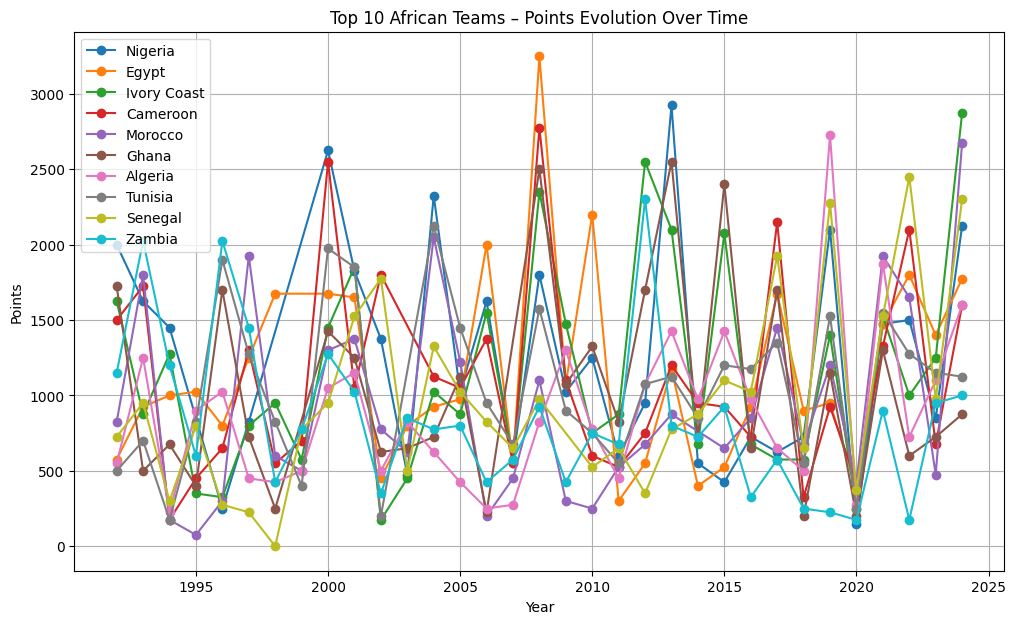

In [35]:
# Ranking Evolution Over Time
## 1. Original Line Plot with markers
plt.figure(figsize=(12,7))

for team in top10:
    team_data = evolution_df[evolution_df["team"] == team]
    plt.plot(team_data["year"], team_data["POINTS"], marker='o', label=team)

plt.title("Top 10 African Teams – Points Evolution Over Time")
plt.xlabel("Year")
plt.ylabel("Points")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
## 2. Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot_df.T, cmap="YlGnBu", linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Points'})
plt.title("Top 10 African Teams – Points Heatmap")
plt.xlabel("Year")
plt.ylabel("Team")
plt.show()

NameError: name 'pivot_df' is not defined

<Figure size 1200x600 with 0 Axes>

## Head-to-head

In [ ]:
data.tail()

In [ ]:
hth_columns = ['year', 'home_team', 'away_team', 'home_score', 'away_score']

In [ ]:
# Head-to-Head function
def hth(team           # Required team data
        , vs = None    # Against the desired team or top teams
        , start = 1957 # Start year 
        , end = 2026   # End year
        , year = None  # Required year to filter 
        , data = data  # Dataframe
       ):
    
    # Step 1: Head-to-Head dataframe based on years and ranking of teams in the same period
    if year is None:
        hth_df = data[data["year"].between(start, end)]
        ranking_data = ranking(start = start, end = end)
    else:
        hth_df = data[data["year"] == year]
        ranking_data = ranking(year = year)

    hth_df = hth_df[hth_columns].copy()
    
    # Step 2: Determine against a specific team, top teams, or all teams
    if vs is not None:
        if isinstance(vs, int):
            teams_list = ranking_data.head(vs)["team"].tolist()
        elif isinstance(vs, list):
            teams_list = vs 
        else:
            teams_list = [vs]
    else:
        teams_list = ranking_data["team"].tolist()
    
    records = []

    # Step 3: Loop through each team and each opponent
    for opponent in teams_list:
        if opponent != team: # skip self-match
            
            # Filter team vs opponent dataframe
            df = hth_df[((hth_df["home_team"] == team) & (hth_df["away_team"] == opponent)) |
                ((hth_df["away_team"] == team) & (hth_df["home_team"] == opponent))]

            # compute aggregated stats
            matches_played = len(df)
            wins = sum(
                ((df["home_team"] == team) & (df["home_score"] > df["away_score"])) |
                ((df["away_team"] == team) & (df["away_score"] > df["home_score"])))
            draws = sum(df["home_score"] == df["away_score"])
            losses = matches_played - wins - draws
            
            goals_for = sum(df.apply(lambda row: row["home_score"] if row["home_team"] == team else row["away_score"], axis=1))
            goals_against = sum(df.apply(lambda row: row["away_score"] if row["home_team"] == team else row["home_score"], axis=1))
            
            records.append({
                "team": team,
                "opponent": opponent,
                "opponent_rank": ranking_data.loc[ranking_data["team"] == opponent, "rank"].values[0], 
                "matches_played": matches_played,
                "wins": wins,
                "draws": draws,
                "losses": losses,
                "goals_for": goals_for,
                "goals_against": goals_against
            })
    
    aggregated_df = pd.DataFrame(records).sort_values(by=['matches_played'],ascending=False).reset_index(drop=True)
    return aggregated_df

### Result Samples

In [ ]:
# Egypt head-to-head games between 1992 and 2026 against the top 10 teams during the same period
hth("Egypt", vs = 10, start = 1992, end = 2026)

In [ ]:
hth("Egypt", "Senegal")

In [ ]:
hth("Egypt", ["Algeria", "Morocco", "Tunisia"])

### Egypt Head to Head Plot

In [ ]:
# Egypt Head-to-Head vs Top African Teams (1992-2026)
egy_hth = hth("Egypt", vs = 10, start = 1992, end = 2026)

plt.figure(figsize=(14,8))

bottom_draws = egy_hth['wins']
bottom_losses = egy_hth['wins'] + egy_hth['draws']

plt.bar(egy_hth['opponent'], egy_hth['wins'], label='Wins', color='green')
plt.bar(egy_hth['opponent'], egy_hth['draws'], bottom=bottom_draws, label='Draws', color='gray')
plt.bar(egy_hth['opponent'], egy_hth['losses'], bottom=bottom_losses, label='Losses', color='red')

plt.title('Egypt Head-to-Head vs Top African Teams (1992-2026)', fontsize=16)
plt.xlabel('Opponent', fontsize=12)
plt.ylabel('Matches', fontsize=12)
plt.legend()

for i, row in egy_hth.iterrows():
    plt.text(i, row['wins']/2, str(row['wins']), ha='center', color='white', fontsize=10)
    plt.text(i, row['wins'] + row['draws']/2, str(row['draws']), ha='center', color='white', fontsize=10)
    plt.text(i, row['wins'] + row['draws'] + row['losses']/2, str(row['losses']), ha='center', color='white', fontsize=10)

plt.show()

## Summary Plots

### Top Teams by Total Points

In [ ]:
df_sorted = total_data.sort_values("total_points", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(df_sorted["team"], df_sorted["POINTS"])
plt.title("African Teams Ranking by POINTS")
plt.ylabel("POINTS")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Goal Difference vs Total Points (Validate Logic)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(total_data["GD"], total_data["total_points"])

for i in range(len(total_data)):
    plt.text(total_data["GD"].iloc[i], total_data["total_points"].iloc[i], total_data["team"].iloc[i])

plt.xlabel("Goal Difference (GD)")
plt.ylabel("Total Points")
plt.title("Goal Difference vs Total Points")
plt.grid(True)
plt.show()


### Win Percentage vs Ranking

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(total_data["wins_%"], total_data["rank"])

for i in range(len(total_data)):
    plt.text(total_data["wins_%"].iloc[i], total_data["rank"].iloc[i], total_data["team"].iloc[i])

plt.gca().invert_yaxis()
plt.xlabel("Win Percentage")
plt.ylabel("Rank")
plt.title("Win Percentage vs Rank")
plt.grid(True)
plt.show()

### Goals For vs Goals Against (Offense vs Defense)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(total_data["GF"], total_data["GA"])

for i in range(len(total_data)):
    plt.text(total_data["GF"].iloc[i], total_data["GA"].iloc[i], total_data["team"].iloc[i])

plt.xlabel("Goals For (Attack)")
plt.ylabel("Goals Against (Defense)")
plt.title("Attack vs Defense Comparison")
plt.grid(True)
plt.show()


### Wins / Draws / Losses Distribution (Stacked Bar)

In [ ]:
teams = total_data["team"]
wins = total_data["wins"]
draws = total_data["draws"]
losses = total_data["losses"]

plt.figure(figsize=(10,6))

plt.bar(teams, wins, label="Wins")
plt.bar(teams, draws, bottom=wins, label="Draws")
plt.bar(teams, losses, bottom=wins+draws, label="Losses")

plt.xticks(rotation=90)
plt.title("Match Results Distribution per Team")
plt.ylabel("Number of Matches")
plt.legend()
plt.tight_layout()
plt.show()
